# Principal components and low-rank approximation
This notebook reproduces the standardized College analysis in Lecture 17. It implements PCA from the covariance eigendecomposition before comparing with scikit-learn.

In [1]:
# Colab opens this notebook on its own, so fetch the data files that sit
# beside it in the course repository. Running locally, this does nothing.
from pathlib import Path as _Path
import urllib.request as _req
_RAW = 'https://raw.githubusercontent.com/ZhuoranYang/sds265-fall26/main/demos/14-pca-low-rank/'
for _name in ['College.csv', 'OlivettiFaces.npz', 'SklearnDigits.csv', 'nasa-blue-marble.jpg']:
    if not _Path(_name).exists():
        _req.urlretrieve(_RAW + _name, _name)

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

college = pd.read_csv('College.csv').rename(columns={'Unnamed: 0': 'College'})
college.shape, college.head(3)

((777, 19),
                         College Private  Apps  Accept  Enroll  Top10perc  \
 0  Abilene Christian University     Yes  1660    1232     721         23   
 1            Adelphi University     Yes  2186    1924     512         16   
 2                Adrian College     Yes  1428    1097     336         22   
 
    Top25perc  F.Undergrad  P.Undergrad  Outstate  Room.Board  Books  Personal  \
 0         52         2885          537      7440        3300    450      2200   
 1         29         2683         1227     12280        6450    750      1500   
 2         50         1036           99     11250        3750    400      1165   
 
    PhD  Terminal  S.F.Ratio  perc.alumni  Expend  Grad.Rate  
 0   70        78       18.1           12    7041         60  
 1   29        30       12.2           16   10527         56  
 2   53        66       12.9           30    8735         54  )

## Implement PCA from the covariance matrix
Centering and scaling are fitted transformations. The eigenvectors of the standardized covariance matrix are the principal directions.

In [2]:
features = ['Apps', 'Accept', 'Enroll', 'Top10perc', 'F.Undergrad', 'Outstate',
            'Room.Board', 'PhD', 'S.F.Ratio', 'perc.alumni', 'Expend', 'Grad.Rate']
raw = college[features].to_numpy(float)
mean = raw.mean(axis=0)
scale = raw.std(axis=0, ddof=0)
X = (raw - mean) / scale
covariance = X.T @ X / len(X)
eigenvalues, eigenvectors = np.linalg.eigh(covariance)
order = np.argsort(eigenvalues)[::-1]
eigenvalues, eigenvectors = eigenvalues[order], eigenvectors[:, order]
scores = X @ eigenvectors
ratio = eigenvalues / eigenvalues.sum()
pd.Series(np.cumsum(ratio), index=np.arange(1, len(features) + 1), name='cumulative variance')

1     0.360123
2     0.685884
3     0.753544
4     0.815443
5     0.869837
6     0.907325
7     0.939489
8     0.961785
9     0.980034
10    0.994760
11    0.997998
12    1.000000
Name: cumulative variance, dtype: float64

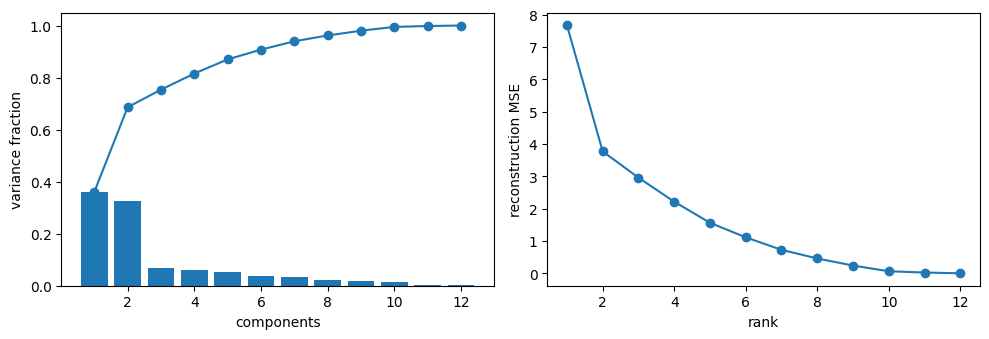

In [3]:
ranks = np.arange(1, len(features) + 1)
errors = []
for rank in ranks:
    V = eigenvectors[:, :rank]
    reconstructed = (X @ V) @ V.T
    errors.append(np.mean(np.sum((X - reconstructed) ** 2, axis=1)))
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].bar(ranks, ratio); axes[0].plot(ranks, np.cumsum(ratio), marker='o')
axes[0].set(xlabel='components', ylabel='variance fraction')
axes[1].plot(ranks, errors, marker='o'); axes[1].set(xlabel='rank', ylabel='reconstruction MSE')
plt.tight_layout()

## Compare with the library implementation
Only after the eigendecomposition is explicit do we call the production implementation. Component signs may differ.

In [4]:
library_X = StandardScaler().fit_transform(raw)
library_pca = PCA().fit(library_X)
np.allclose(eigenvalues, library_pca.explained_variance_ * (len(X) - 1) / len(X)), np.cumsum(library_pca.explained_variance_ratio_)[:6]

(True,
 array([0.36012302, 0.68588397, 0.75354411, 0.81544263, 0.86983683,
        0.90732516]))

## Eigenfaces: the same method on photographs
The College table had 12 columns of different units, so it was standardized. A face
is 4,096 pixels in one shared unit, so it is only centered. Everything else is identical:
take the SVD of the centered matrix and keep the leading directions.

In [5]:
from sklearn.neighbors import KNeighborsClassifier

stored = np.load('OlivettiFaces.npz')
faces, person = stored['images'].astype(float) / 255, stored['person']
flat = faces.reshape(len(faces), -1)

# Seven photographs of each person for fitting, three held out.
generator = np.random.default_rng(26517)
train, test = [], []
for who in range(int(person.max()) + 1):
    index = np.flatnonzero(person == who)
    generator.shuffle(index)
    train += list(index[:7]); test += list(index[7:])
train, test = np.array(train), np.array(test)
flat.shape, len(train), len(test)

((400, 4096), 280, 120)

### The mean face and the leading directions
A loading vector has one entry per pixel, so it can be drawn as an image.

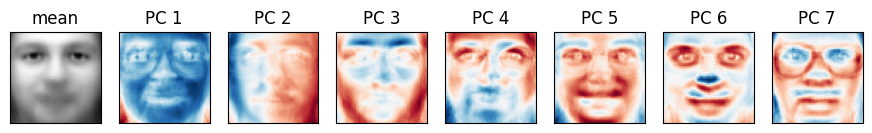

In [6]:
face_pca = PCA(n_components=150).fit(flat[train])
fig, axes = plt.subplots(1, 8, figsize=(11, 1.7))
axes[0].imshow(face_pca.mean_.reshape(64, 64), cmap='gray'); axes[0].set_title('mean')
for j, ax in enumerate(axes[1:]):
    ax.imshow(face_pca.components_[j].reshape(64, 64), cmap='RdBu')
    ax.set_title(f'PC {j + 1}')
for ax in axes: ax.set_xticks([]); ax.set_yticks([])
plt.show()

### Does the compression cost us anything?
Match each held-out photograph to its nearest training photograph, first on all 4,096
pixels and then on the first `r` principal coordinates.

In [7]:
baseline = KNeighborsClassifier(1).fit(flat[train], person[train]).score(flat[test], person[test])
rows = []
for r in [2, 5, 10, 20, 40, 80, 150]:
    fitted = PCA(n_components=r).fit(flat[train])
    model = KNeighborsClassifier(1).fit(fitted.transform(flat[train]), person[train])
    rows.append((r, fitted.explained_variance_ratio_.sum(),
                 model.score(fitted.transform(flat[test]), person[test])))
print(f'all 4096 pixels: {baseline:.3f}')
pd.DataFrame(rows, columns=['r', 'variance kept', 'accuracy']).round(3)

all 4096 pixels: 0.892


,r,variance kept,accuracy
0,2,0.384,0.267
1,5,0.545,0.683
2,10,0.662,0.842
3,20,0.769,0.908
4,40,0.859,0.908
5,80,0.929,0.908
6,150,0.976,0.892


## Part 2 --- every figure in the slides

These cells are the code that produced the figures in the deck, with each file write replaced by an inline plot.

In [8]:
from pathlib import Path
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# The course palette and figure sizes, copied from slides/figures/sds265_style.py
BLUE, BLUE_BRIGHT, RED, GREEN = '#00356B', '#286DC0', '#7A3E47', '#5B7864'
INK, MUTED, RULE, BLUE_PALE = '#202A35', '#66727E', '#D8E0E8', '#F2F6FA'
BLUE_FILL, RED_FILL, GREEN_FILL = '#7B8FA3', '#A3838A', '#8FA394'
CYCLE = [BLUE, RED, GREEN, BLUE_BRIGHT, MUTED]
TEXTWIDTH, TEXTHEIGHT = 5.63, 3.09
FULL, FULL_TALL, FULL_SHORT = (TEXTWIDTH, 2.0), (TEXTWIDTH, 2.35), (TEXTWIDTH, 1.7)
HALF, HALF_TALL = (2.70, 2.05), (2.70, 2.45)

def use_course_style():
    mpl.rcParams.update({'figure.dpi': 130, 'font.size': 9, 'axes.titlecolor': BLUE,
                         'axes.edgecolor': MUTED, 'axes.linewidth': .7,
                         'axes.spines.top': False, 'axes.spines.right': False,
                         'xtick.color': MUTED, 'ytick.color': MUTED,
                         'legend.frameon': False, 'lines.linewidth': 1.8,
                         'axes.prop_cycle': mpl.cycler(color=CYCLE)})

def save(fig, *paths):     # the deck writes files; the notebook shows the plot
    plt.show()
    return Path(paths[0]) if paths else Path('figure.pdf')

use_course_style()
# The figure scripts locate the data through OUT.parents[2]; point OUT at the
# directory the deck uses because figure names are derived from it.
COURSE = Path.cwd().parents[1]
OUT = COURSE / 'slides' / 'figures' / '14-pca-low-rank'
NOTES = COURSE / 'lectures' / 'figures'

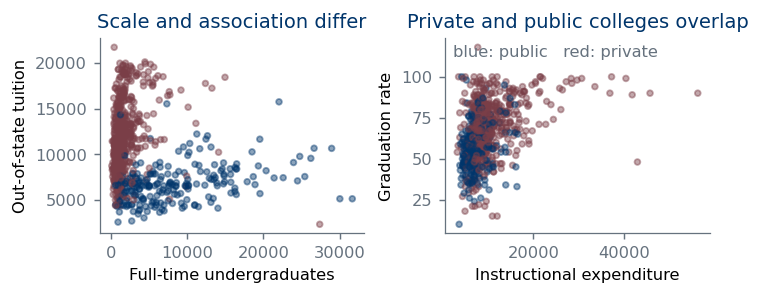

In [9]:
from __future__ import annotations


import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler



SEED = 26517
rng = np.random.default_rng(SEED)

college = pd.read_csv('College.csv').rename(columns={"Unnamed: 0": "College"})
features = ["Apps", "Accept", "Enroll", "Top10perc", "F.Undergrad", "Outstate",
            "Room.Board", "PhD", "S.F.Ratio", "perc.alumni", "Expend", "Grad.Rate"]
X_raw = college[features].to_numpy(float)
X = StandardScaler().fit_transform(X_raw)
pca = PCA().fit(X)
scores = pca.transform(X)


def cloud() -> np.ndarray:
    base = rng.normal(size=(72, 2))
    return base @ np.array([[2.1, 1.15], [0.15, 0.55]])


def college_data() -> None:
    colors = np.where(college["Private"].eq("Yes"), RED, BLUE)
    fig, axes = plt.subplots(1, 2, figsize=FULL_TALL)
    axes[0].scatter(college["F.Undergrad"], college["Outstate"], c=colors, s=10, alpha=.45)
    axes[0].set(xlabel="Full-time undergraduates", ylabel="Out-of-state tuition",
                title="Scale and association differ")
    axes[1].scatter(college["Expend"], college["Grad.Rate"], c=colors, s=10, alpha=.45)
    axes[1].set(xlabel="Instructional expenditure", ylabel="Graduation rate",
                title="Private and public colleges overlap")
    axes[1].text(.03, .97, "blue: public   red: private", transform=axes[1].transAxes,
                 va="top", color=MUTED)
    fig.tight_layout(w_pad=.8)
    save(fig, OUT / "college-data.pdf", OUT / "college-data.svg")

college_data()

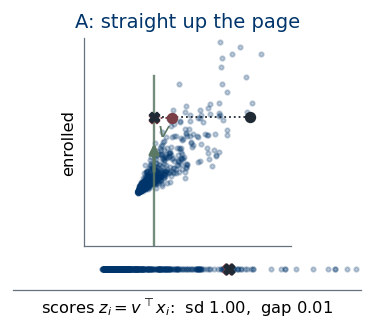

  A: straight up the page  sd 1.00  gap 0.01


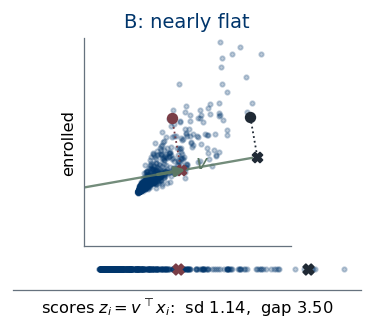

  B: nearly flat           sd 1.14  gap 3.50


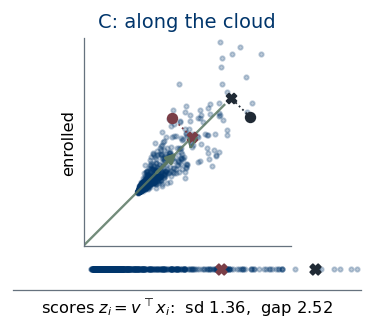

  C: along the cloud       sd 1.36  gap 2.52


In [10]:
def candidate_directions() -> None:
    """One figure per candidate direction, each large enough to read."""
    from matplotlib.patches import FancyArrowPatch

    pair = ["Apps", "Enroll"]
    values = StandardScaler().fit_transform(college[pair].to_numpy(float))
    names = college["College"].to_numpy().astype(str)
    a_index = int(np.flatnonzero(np.char.startswith(names, "Southwest Missouri"))[0])
    b_index = int(np.flatnonzero(np.char.startswith(names, "University of California at Berkeley"))[0])

    best_angle = float(np.degrees(np.arctan2(*PCA(n_components=1).fit(values).components_[0][::-1])))
    panels = [(90.0, "a", "A: straight up the page"),
              (10.0, "b", "B: nearly flat"),
              (best_angle, "c", "C: along the cloud")]

    for degree, tag, label in panels:
        theta = np.deg2rad(degree)
        v = np.array([np.cos(theta), np.sin(theta)])
        scores = values @ v
        span = (-3.2, 6.2)
        fig, axes = plt.subplots(2, 1, figsize=(2.95, 2.62), sharex=True,
                                 gridspec_kw={"height_ratios": [5, 1]})
        top = axes[0]
        top.scatter(values[:, 0], values[:, 1], s=6, color=BLUE, alpha=.25)
        line = np.array([-4.5, 4.5])
        top.plot(line * v[0], line * v[1], color=GREEN, lw=1.3, alpha=.85)
        top.add_patch(FancyArrowPatch((0, 0), tuple(1.6 * v), arrowstyle="-|>",
                                      mutation_scale=11, color=GREEN, lw=1.8, zorder=5))
        top.text(1.75 * v[0] + .15, 1.75 * v[1], "$v$", color=GREEN, fontsize=11, zorder=5)
        for index, colour in ((a_index, RED), (b_index, INK)):
            point, foot = values[index], scores[index] * v
            top.scatter(*point, s=28, color=colour, zorder=4)
            top.plot([point[0], foot[0]], [point[1], foot[1]], color=colour, lw=1.0, ls=":")
            top.scatter(*foot, s=30, color=colour, marker="X", zorder=4)
        top.set(title=label, aspect="equal", xlim=span, ylim=span,
                ylabel="enrolled", xticks=[], yticks=[])

        bottom = axes[1]
        bottom.scatter(scores, np.zeros_like(scores), s=6, color=BLUE, alpha=.25)
        for index, colour in ((a_index, RED), (b_index, INK)):
            bottom.scatter(scores[index], 0, s=34, color=colour, marker="X", zorder=4)
        gap = abs(scores[a_index] - scores[b_index])
        bottom.set(yticks=[], xlim=span, xticks=[],
                   xlabel=f"scores $z_i=v^\\top x_i$:  sd {scores.std():.2f},  gap {gap:.2f}")
        bottom.spines["left"].set_visible(False)
        fig.tight_layout(h_pad=.15)
        save(fig, OUT / f"direction-{tag}.pdf", OUT / f"direction-{tag}.svg")
        print(f"  {label:24s} sd {scores.std():.2f}  gap {gap:.2f}")

candidate_directions()

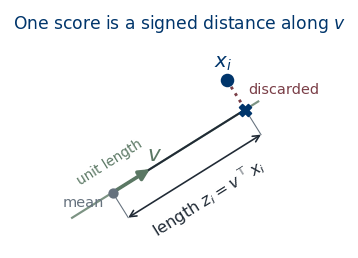

In [11]:
def projection_anatomy() -> None:
    """What one score is: the signed distance along v to the foot of the point."""
    from matplotlib.patches import FancyArrowPatch

    theta = np.deg2rad(32)
    v = np.array([np.cos(theta), np.sin(theta)])
    x = np.array([2.4, 2.35])
    z = float(x @ v)
    foot = z * v

    fig, ax = plt.subplots(figsize=(TEXTWIDTH * 0.66, 2.05))
    line = np.array([-1.0, 3.6])
    ax.plot(line * v[0], line * v[1], color=GREEN, lw=1.2, alpha=.8)
    ax.add_patch(FancyArrowPatch((0, 0), tuple(v), arrowstyle="-|>", mutation_scale=12,
                                 color=GREEN, lw=2.0, zorder=5))
    normal = np.array([-v[1], v[0]])
    ax.text(*(v * 1.16 + normal * 0.20), "$v$", color=GREEN, fontsize=12,
            ha="center", va="center")
    ax.text(*(v * 0.28 + normal * 0.42), "unit length", color=GREEN, fontsize=7.5,
            ha="center", va="bottom", rotation=np.degrees(theta), rotation_mode="anchor")

    ax.scatter(*x, s=42, color=BLUE, zorder=6)
    ax.text(x[0] - .08, x[1] + .26, "$x_i$", color=BLUE, fontsize=11, ha="center")
    ax.scatter(*foot, s=42, color=BLUE, marker="X", zorder=6)
    ax.plot([x[0], foot[0]], [x[1], foot[1]], color=RED, ls=":", lw=1.6)
    ax.text((x[0] + foot[0]) / 2 + .26, (x[1] + foot[1]) / 2 + .10,
            "discarded", color=RED, fontsize=8, ha="left", va="center")
    # The score is a number, not the segment.  Measure it with a dimension line
    # set off to the side, the way a length is marked on a drawing, so the arrow
    # cannot be read as an object living in the plane.
    ax.plot([0, foot[0]], [0, foot[1]], color=INK, lw=1.1, zorder=4)
    gap = -0.62 * normal
    for endpoint in ((0, 0), tuple(foot)):
        ax.plot([endpoint[0], endpoint[0] + gap[0]], [endpoint[1], endpoint[1] + gap[1]],
                color=MUTED, lw=.6, zorder=2)
    ax.annotate("", xy=tuple(foot + gap), xytext=tuple(gap),
                arrowprops=dict(arrowstyle="<->", color=INK, lw=.9,
                                shrinkA=0, shrinkB=0, linestyle="-"))
    ax.text(*(foot / 2 + 1.55 * gap), r"length $z_i=v^\top x_i$", color=INK,
            fontsize=9, ha="center", va="top", rotation=np.degrees(theta),
            rotation_mode="anchor")
    ax.scatter(0, 0, s=22, color=MUTED, zorder=6)
    ax.text(-.62, -.30, "mean", color=MUTED, fontsize=8, ha="center")

    ax.set(xlim=(-1.3, 4.1), ylim=(-1.1, 3.2), aspect="equal", xticks=[], yticks=[])
    for side in ("left", "bottom"):
        ax.spines[side].set_visible(False)
    ax.set_title("One score is a signed distance along $v$", fontsize=9.5, color=BLUE)
    save(fig, OUT / "projection-anatomy.pdf", OUT / "projection-anatomy.svg")

projection_anatomy()

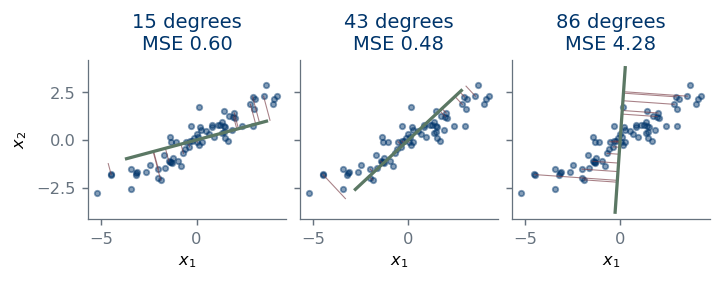

In [12]:
def rotating_projection() -> None:
    data = cloud()
    angles = [15, 43, 86]
    fig, axes = plt.subplots(1, 3, figsize=FULL_TALL, sharex=True, sharey=True)
    for ax, degree in zip(axes, angles):
        theta = np.deg2rad(degree)
        v = np.array([np.cos(theta), np.sin(theta)])
        projected = (data @ v)[:, None] * v
        ax.scatter(data[:, 0], data[:, 1], s=9, color=BLUE, alpha=.48)
        for point, projection in zip(data[::5], projected[::5]):
            ax.plot([point[0], projection[0]], [point[1], projection[1]], color=RED, lw=.6, alpha=.65)
        line = np.array([-3.8, 3.8])
        ax.plot(line * v[0], line * v[1], color=GREEN)
        error = np.mean(np.sum((data - projected) ** 2, axis=1))
        ax.set(title=f"{degree} degrees\nMSE {error:.2f}", xlabel="$x_1$", aspect="equal")
    axes[0].set_ylabel("$x_2$")
    fig.tight_layout(w_pad=.45)
    save(fig, OUT / "rotating-projection.pdf", OUT / "rotating-projection.svg")

rotating_projection()

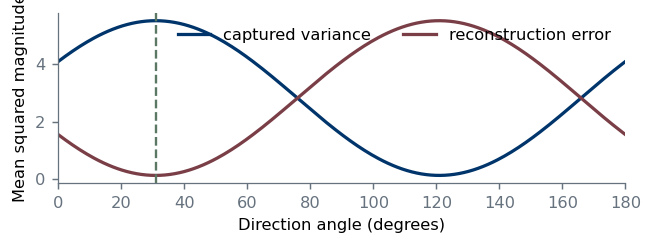

In [13]:
def pca_duality() -> None:
    data = cloud()
    theta = np.linspace(0, np.pi, 240)
    captured = []
    total = np.mean(np.sum(data ** 2, axis=1))
    for angle in theta:
        v = np.array([np.cos(angle), np.sin(angle)])
        captured.append(np.mean((data @ v) ** 2))
    captured = np.asarray(captured)
    residual = total - captured
    fig, ax = plt.subplots(figsize=FULL_SHORT)
    degrees = np.rad2deg(theta)
    ax.plot(degrees, captured, color=BLUE, label="captured variance")
    ax.plot(degrees, residual, color=RED, label="reconstruction error")
    optimum = int(np.argmax(captured))
    ax.axvline(degrees[optimum], color=GREEN, ls="--", lw=1.3)
    ax.set(xlabel="Direction angle (degrees)", ylabel="Mean squared magnitude", xlim=(0, 180))
    ax.legend(ncol=2, loc="upper right")
    save(fig, OUT / "pca-duality.pdf", OUT / "pca-duality.svg")

pca_duality()

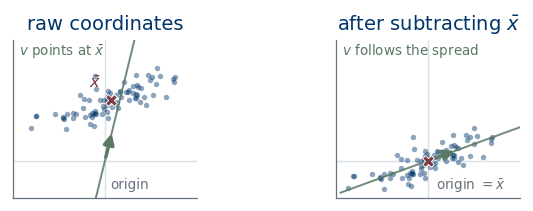

(7.952084736364611, 64.18446241770982)

In [14]:
def centering() -> tuple[float, float]:
    """Why the mean is subtracted before any direction is chosen.

    Both panels show the same cloud on the same axes.  On the left the origin
    is wherever the measuring units happened to put it, and the direction
    maximizing the average squared score is the top eigenvector of the second
    moment -- which lines up with the mean, not with the spread.  On the right
    the mean has been moved to the origin and the same criterion follows the
    elongation of the cloud.
    """
    from matplotlib.patches import FancyArrowPatch

    # The cloud is stretched along 20 degrees but sits well above the origin, so
    # "points at the mean" and "follows the spread" are visibly different lines.
    spread = np.deg2rad(20.0)
    basis = np.array([[np.cos(spread), np.sin(spread)], [-np.sin(spread), np.cos(spread)]])
    generator = np.random.default_rng(SEED)
    data = (generator.normal(size=(80, 2)) * [2.35, .55]) @ basis + np.array([.4, 4.2])
    mean = data.mean(axis=0)
    centered = data - mean

    def top_direction(values: np.ndarray) -> np.ndarray:
        # No centering inside: this is the raw second moment (1/n) X^T X.
        eigenvalues, eigenvectors = np.linalg.eigh(values.T @ values / len(values))
        vector = eigenvectors[:, int(np.argmax(eigenvalues))]
        return vector if vector @ values.mean(axis=0) >= 0 else -vector

    uncentered_v = top_direction(data)
    centered_v = top_direction(centered)
    if centered_v[0] < 0:
        centered_v = -centered_v

    def angle(u: np.ndarray, w: np.ndarray) -> float:
        cosine = abs(u @ w) / (np.linalg.norm(u) * np.linalg.norm(w))
        return float(np.degrees(np.arccos(np.clip(cosine, -1, 1))))

    span_x, span_y = (-6.4, 6.4), (-2.6, 8.4)
    fig, axes = plt.subplots(1, 2, figsize=FULL_SHORT, sharey=True)
    panels = [
        (axes[0], data, np.zeros(2), uncentered_v, "raw coordinates"),
        (axes[1], centered, np.zeros(2), centered_v, "after subtracting $\\bar x$"),
    ]
    for ax, points, anchor, vector, title in panels:
        ax.axhline(0, color=RULE, lw=.8, zorder=0)
        ax.axvline(0, color=RULE, lw=.8, zorder=0)
        ax.scatter(points[:, 0], points[:, 1], s=9, color=BLUE, alpha=.45, linewidths=0)
        line = np.array([-6.5, 12.0])
        ax.plot(anchor[0] + line * vector[0], anchor[1] + line * vector[1],
                color=GREEN, lw=1.1, alpha=.85)
        ax.add_patch(FancyArrowPatch(tuple(anchor), tuple(anchor + 2.2 * vector),
                                     arrowstyle="-|>", mutation_scale=12,
                                     color=GREEN, lw=1.9, zorder=5))
        centre = points.mean(axis=0)
        ax.scatter(*centre, s=42, marker="X", color=RED, zorder=6,
                   edgecolors="white", linewidths=.5)
        ax.set(title=title, aspect="equal", xlim=span_x, ylim=span_y,
               xticks=[], yticks=[])
    axes[0].text(.35, -1.9, "origin", color=MUTED, fontsize=7.5)
    axes[0].text(mean[0] - 1.5, mean[1] + .9, "$\\bar x$", color=RED, fontsize=9)
    axes[0].text(-6.0, 7.4, "$v$ points at $\\bar x$", color=GREEN, fontsize=7.5)
    axes[1].text(.5, -1.9, "origin $=\\bar x$", color=MUTED, fontsize=7.5)
    axes[1].text(-6.0, 7.4, "$v$ follows the spread", color=GREEN, fontsize=7.5)
    fig.tight_layout(w_pad=.6)
    save(fig, OUT / "centering.pdf", OUT / "centering.svg")
    return angle(uncentered_v, mean), angle(centered_v, mean)

centering()

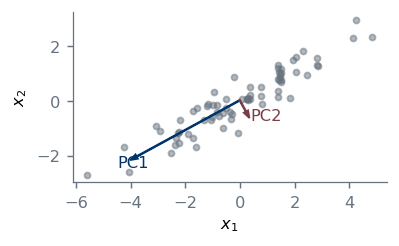

In [15]:
def principal_axes() -> None:
    data = cloud()
    values, vectors = np.linalg.eigh(np.cov(data.T))
    order = np.argsort(values)[::-1]
    values, vectors = values[order], vectors[:, order]
    fig, ax = plt.subplots(figsize=FULL_SHORT)
    ax.scatter(data[:, 0], data[:, 1], s=11, color=MUTED, alpha=.5)
    center = data.mean(axis=0)
    for index, color in enumerate([BLUE, RED]):
        vector = vectors[:, index]
        length = 2 * np.sqrt(values[index])
        ax.arrow(center[0], center[1], length * vector[0], length * vector[1], color=color,
                 width=.025, head_width=.18, length_includes_head=True)
        ax.text(*(center + 1.12 * length * vector), f"PC{index + 1}", color=color)
    ax.set(xlabel="$x_1$", ylabel="$x_2$", aspect="equal")
    save(fig, OUT / "principal-axes.pdf", OUT / "principal-axes.svg")

principal_axes()

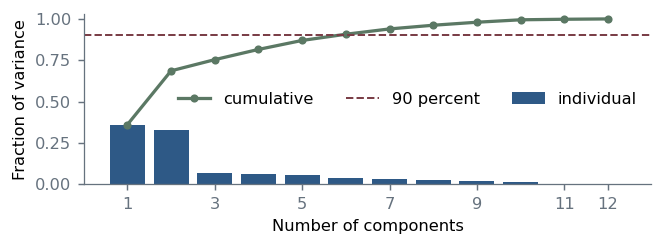

In [16]:
def college_scree() -> None:
    ratio = pca.explained_variance_ratio_
    cumulative = np.cumsum(ratio)
    components = np.arange(1, len(ratio) + 1)
    fig, ax = plt.subplots(figsize=FULL_SHORT)
    ax.bar(components, ratio, color=BLUE, alpha=.82, label="individual")
    ax.plot(components, cumulative, "o-", color=GREEN, ms=3.5, label="cumulative")
    ax.axhline(.90, color=RED, ls="--", lw=1.1, label="90 percent")
    # A longer y label does not fit the short figure height and gets clipped.
    ax.set(xlabel="Number of components", ylabel="Fraction of variance",
           xticks=[1, 3, 5, 7, 9, 11, 12], ylim=(0, 1.03))
    ax.legend(ncol=3, loc="center right")
    save(fig, OUT / "college-scree.pdf", OUT / "college-scree.svg")

college_scree()

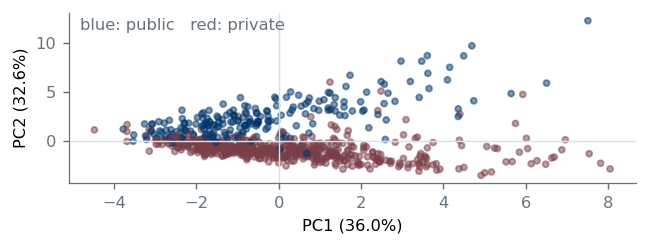

In [17]:
def score_plot() -> None:
    colors = np.where(college["Private"].eq("Yes"), RED, BLUE)
    fig, ax = plt.subplots(figsize=FULL_SHORT)
    ax.scatter(scores[:, 0], scores[:, 1], c=colors, s=11, alpha=.5)
    ax.axhline(0, color=RULE, lw=.8)
    ax.axvline(0, color=RULE, lw=.8)
    ax.set(xlabel=f"PC1 ({100 * pca.explained_variance_ratio_[0]:.1f}%)",
           ylabel=f"PC2 ({100 * pca.explained_variance_ratio_[1]:.1f}%)")
    ax.text(.02, .97, "blue: public   red: private", transform=ax.transAxes, va="top", color=MUTED)
    save(fig, OUT / "college-scores.pdf", OUT / "college-scores.svg")

score_plot()

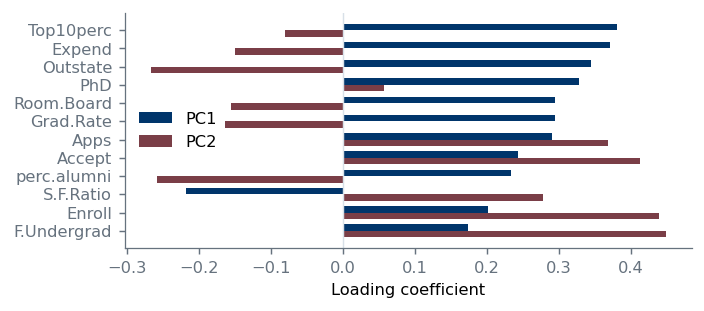

In [18]:
def loadings() -> None:
    loading = pca.components_[:2].T
    order = np.argsort(np.abs(loading[:, 0]))[::-1]
    positions = np.arange(len(features))
    fig, ax = plt.subplots(figsize=FULL_TALL)
    width = .36
    ax.barh(positions - width / 2, loading[order, 0], height=width, color=BLUE, label="PC1")
    ax.barh(positions + width / 2, loading[order, 1], height=width, color=RED, label="PC2")
    ax.set(yticks=positions, yticklabels=np.asarray(features)[order], xlabel="Loading coefficient")
    ax.axvline(0, color=RULE, lw=.8)
    ax.invert_yaxis()
    ax.legend()
    save(fig, OUT / "college-loadings.pdf", OUT / "college-loadings.svg")

loadings()

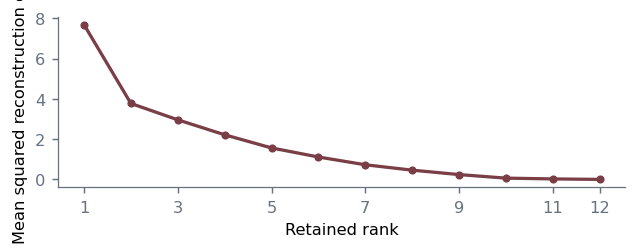

In [19]:
def reconstruction_curve() -> None:
    errors = [np.mean(np.sum((X - scores[:, :r] @ pca.components_[:r]) ** 2, axis=1))
              for r in range(1, len(features) + 1)]
    fig, ax = plt.subplots(figsize=FULL_SHORT)
    ax.plot(range(1, len(features) + 1), errors, "o-", color=RED, ms=3.5)
    ax.set(xlabel="Retained rank", ylabel="Mean squared reconstruction error",
           xticks=[1, 3, 5, 7, 9, 11, 12])
    save(fig, OUT / "college-reconstruction.pdf", OUT / "college-reconstruction.svg")

reconstruction_curve()

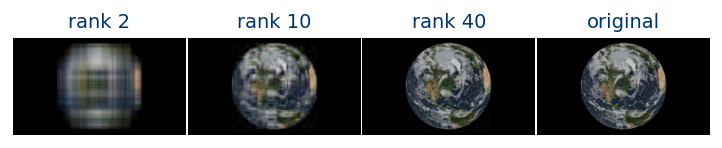

In [20]:
def low_rank_image() -> None:
    image = Image.open('nasa-blue-marble.jpg').convert("RGB").resize((384, 216))
    array = np.asarray(image, dtype=float) / 255
    decompositions = [np.linalg.svd(array[:, :, channel], full_matrices=False) for channel in range(3)]
    fig, axes = plt.subplots(1, 4, figsize=FULL_TALL)
    for ax, rank in zip(axes[:3], [2, 10, 40]):
        reconstructed = np.stack([(u[:, :rank] * s[:rank]) @ vt[:rank]
                                  for u, s, vt in decompositions], axis=2)
        ax.imshow(np.clip(reconstructed, 0, 1))
        ax.set_title(f"rank {rank}")
    axes[3].imshow(array)
    axes[3].set_title("original")
    for ax in axes:
        ax.axis("off")
    fig.tight_layout(w_pad=.12)
    save(fig, OUT / "low-rank-earth.pdf", OUT / "low-rank-earth.svg")

low_rank_image()

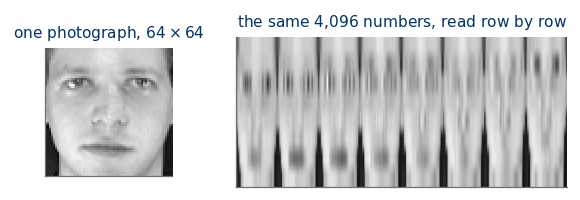

In [21]:
# --- Eigenfaces: the classic image experiment ------------------------------
#
# The AT&T (ORL) face database, 400 images of 40 people at 64x64.  It is
# The local copy beside this notebook keeps the demo offline and deterministic.
FACES_CACHE = Path('OlivettiFaces.npz')
FACE_SHAPE = (64, 64)


def load_faces() -> tuple[np.ndarray, np.ndarray]:
    cached = np.load(FACES_CACHE)
    return cached["images"].astype(float) / 255.0, cached["person"]


def face_split() -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """Seven training and three test photographs of each of the 40 people."""
    images, person = load_faces()
    flat = images.reshape(len(images), -1)
    generator = np.random.default_rng(SEED)
    train, test = [], []
    for who in range(int(person.max()) + 1):
        index = np.flatnonzero(person == who)
        generator.shuffle(index)
        train += list(index[:7])
        test += list(index[7:])
    return flat, person, np.array(train), np.array(test)


def face_as_vector() -> None:
    """One photograph is one row: 4,096 numbers laid end to end."""
    images, _ = load_faces()
    face = images[0]
    fig = plt.figure(figsize=(TEXTWIDTH * 0.92, 1.5))
    grid = fig.add_gridspec(1, 2, width_ratios=[1, 2.6], wspace=.28)
    left = fig.add_subplot(grid[0])
    left.imshow(face, cmap="gray")
    left.set_title("one photograph, $64\\times64$", fontsize=8.5, color=BLUE)
    right = fig.add_subplot(grid[1])
    right.imshow(face.ravel().reshape(8, 512), cmap="gray", aspect="auto")
    right.set_title("the same $4{,}096$ numbers, read row by row",
                    fontsize=8.5, color=BLUE)
    for ax in (left, right):
        ax.set_xticks([]); ax.set_yticks([])
    save(fig, OUT / "face-as-vector.pdf", OUT / "face-as-vector.svg")

face_as_vector()

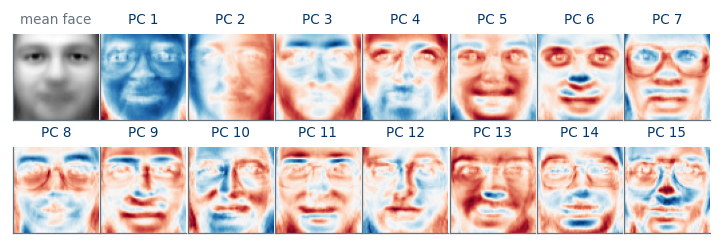

In [22]:
def eigenfaces() -> None:
    """The mean face and the leading principal directions, drawn as images."""
    flat, _, train, _ = face_split()
    fit = PCA(n_components=64).fit(flat[train])
    fig, axes = plt.subplots(2, 8, figsize=(TEXTWIDTH, 1.95))
    flatten = axes.ravel()
    flatten[0].imshow(fit.mean_.reshape(FACE_SHAPE), cmap="gray")
    flatten[0].set_title("mean face", fontsize=7.5, color=MUTED)
    for position, ax in enumerate(flatten[1:]):
        ax.imshow(fit.components_[position].reshape(FACE_SHAPE), cmap="RdBu")
        ax.set_title(f"PC {position + 1}", fontsize=7.5, color=BLUE)
    for ax in flatten:
        ax.set_xticks([]); ax.set_yticks([])
    fig.tight_layout(w_pad=.1, h_pad=1.4)
    save(fig, OUT / "eigenfaces.pdf", OUT / "eigenfaces.svg")

eigenfaces()

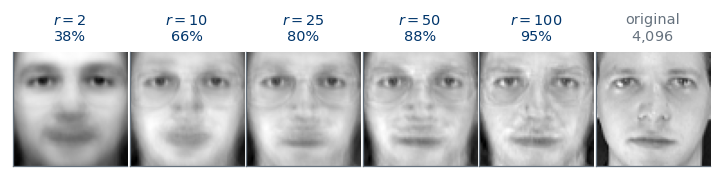

face variance kept: {2: 0.384, 10: 0.662, 25: 0.801, 50: 0.884, 100: 0.948}


In [23]:
def face_reconstruction() -> None:
    """A held-out face rebuilt from an increasing number of components."""
    flat, _, train, test = face_split()
    fit = PCA(n_components=150).fit(flat[train])
    share = np.cumsum(fit.explained_variance_ratio_)
    target = flat[test[1]]
    ranks = [2, 10, 25, 50, 100]
    fig, axes = plt.subplots(1, len(ranks) + 1, figsize=(TEXTWIDTH, 1.45))
    for ax, rank in zip(axes, ranks):
        code = fit.transform(target[None])[:, :rank]
        rebuilt = code @ fit.components_[:rank] + fit.mean_
        ax.imshow(rebuilt.reshape(FACE_SHAPE), cmap="gray")
        ax.set_title(f"$r={rank}$\n{share[rank - 1]:.0%}", fontsize=8, color=BLUE)
    axes[-1].imshow(target.reshape(FACE_SHAPE), cmap="gray")
    axes[-1].set_title("original\n$4{,}096$", fontsize=8, color=MUTED)
    for ax in axes:
        ax.set_xticks([]); ax.set_yticks([])
    fig.tight_layout(w_pad=.15)
    save(fig, OUT / "face-reconstruction.pdf", OUT / "face-reconstruction.svg")
    print("face variance kept:", {r: round(float(share[r - 1]), 3) for r in ranks})

face_reconstruction()

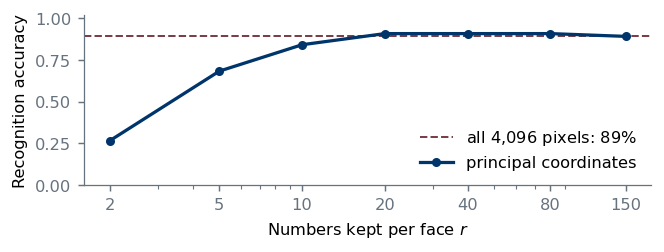

face recognition: {2: 0.267, 5: 0.683, 10: 0.842, 20: 0.908, 40: 0.908, 80: 0.908, 150: 0.892} pixels 0.892


In [24]:
def face_recognition() -> None:
    """Nearest-neighbour recognition on scores against nearest neighbour on pixels."""
    from sklearn.neighbors import KNeighborsClassifier

    flat, person, train, test = face_split()
    baseline = KNeighborsClassifier(1).fit(flat[train], person[train]).score(
        flat[test], person[test])
    ranks = [2, 5, 10, 20, 40, 80, 150]
    accuracy = []
    for rank in ranks:
        fit = PCA(n_components=rank).fit(flat[train])
        model = KNeighborsClassifier(1).fit(fit.transform(flat[train]), person[train])
        accuracy.append(model.score(fit.transform(flat[test]), person[test]))

    fig, ax = plt.subplots(figsize=FULL_SHORT)
    ax.axhline(baseline, color=RED, ls="--", lw=1.1,
               label=f"all $4{{,}}096$ pixels: {baseline:.0%}")
    ax.plot(ranks, accuracy, "o-", color=BLUE, ms=4, label="principal coordinates")
    ax.set(xscale="log", xlabel="Numbers kept per face $r$",
           ylabel="Recognition accuracy", ylim=(0, 1.02),
           xticks=ranks, xticklabels=[str(r) for r in ranks])
    ax.legend(loc="lower right")
    save(fig, OUT / "face-recognition.pdf", OUT / "face-recognition.svg")
    print("face recognition:", {r: round(float(a), 3) for r, a in zip(ranks, accuracy)},
          "pixels", round(float(baseline), 3))

face_recognition()

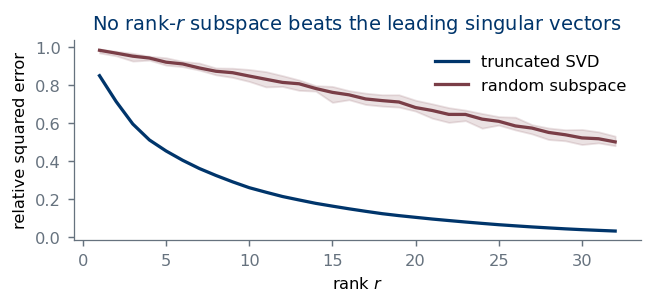

rank 10: pca 0.262  random mean 0.849


In [25]:
# --- Handwritten digits: kept only for the optimality experiment ------------
digits = pd.read_csv('SklearnDigits.csv')
digit_labels = digits["target"].to_numpy(int)
D = digits.drop(columns="target").to_numpy(float)
D_centred = D - D.mean(0)
digit_pca = PCA().fit(D)


def truncation_is_optimal() -> None:
    """Compare the truncated SVD with random subspaces of the same rank."""
    ranks = np.arange(1, 33)
    total = float((D_centred ** 2).sum())
    pca_error = []
    for rank in ranks:
        approx = digit_pca.transform(D)[:, :rank] @ digit_pca.components_[:rank]
        pca_error.append(float(((D_centred - approx) ** 2).sum()) / total)
    random_error = np.zeros((12, len(ranks)))
    for repeat in range(12):
        local = np.random.default_rng(SEED + repeat)
        for j, rank in enumerate(ranks):
            basis = np.linalg.qr(local.normal(size=(D.shape[1], rank)))[0]
            approx = (D_centred @ basis) @ basis.T
            random_error[repeat, j] = float(((D_centred - approx) ** 2).sum()) / total

    fig, ax = plt.subplots(figsize=FULL)
    ax.plot(ranks, pca_error, color=BLUE, label="truncated SVD")
    ax.plot(ranks, random_error.mean(0), color=RED, label="random subspace")
    ax.fill_between(ranks, random_error.min(0), random_error.max(0), color=RED, alpha=.15)
    ax.set(xlabel="rank $r$", ylabel="relative squared error",
           title="No rank-$r$ subspace beats the leading singular vectors")
    ax.legend()
    save(fig, OUT / "truncation-optimal.pdf", OUT / "truncation-optimal.svg")
    print("rank 10: pca", round(pca_error[9], 3), " random mean", round(random_error.mean(0)[9], 3))

truncation_is_optimal()

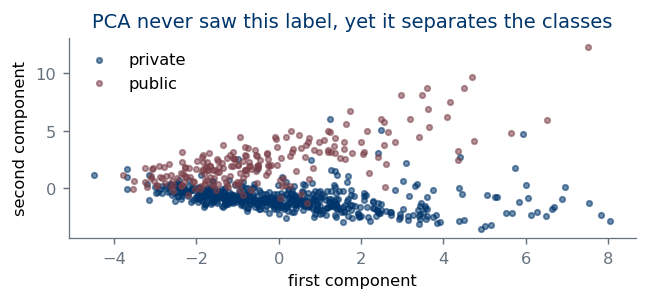

private/public accuracy: 2 components 0.923, all 12 features 0.938


In [26]:
def scores_with_labels() -> None:
    """The College scores, coloured by a label PCA never saw."""
    private = (college["Private"] == "Yes").to_numpy()
    fig, ax = plt.subplots(figsize=FULL)
    ax.scatter(scores[private, 0], scores[private, 1], s=9, alpha=.55, color=BLUE, label="private")
    ax.scatter(scores[~private, 0], scores[~private, 1], s=9, alpha=.55, color=RED, label="public")
    ax.set(xlabel="first component", ylabel="second component",
           title="PCA never saw this label, yet it separates the classes")
    ax.legend()
    save(fig, OUT / "scores-labelled.pdf", OUT / "scores-labelled.svg")
    from sklearn.linear_model import LogisticRegression
    from sklearn.model_selection import cross_val_score
    two = cross_val_score(LogisticRegression(max_iter=2000), scores[:, :2], private, cv=5).mean()
    allp = cross_val_score(LogisticRegression(max_iter=2000), X, private, cv=5).mean()
    print(f"private/public accuracy: 2 components {two:.3f}, all {X.shape[1]} features {allp:.3f}")

scores_with_labels()

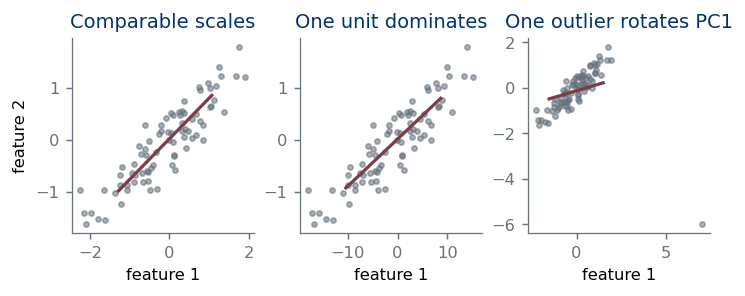

In [27]:
def preprocessing_failures() -> None:
    base = rng.normal(size=(80, 2))
    base[:, 1] = .7 * base[:, 0] + .35 * rng.normal(size=80)
    scaled = base.copy(); scaled[:, 0] *= 8
    outlier = np.vstack([base, [7, -6]])
    datasets = [(base, "Comparable scales"), (scaled, "One unit dominates"), (outlier, "One outlier rotates PC1")]
    fig, axes = plt.subplots(1, 3, figsize=FULL_TALL)
    for ax, (data, title) in zip(axes, datasets):
        covariance = np.cov(data.T)
        vector = np.linalg.eigh(covariance)[1][:, -1]
        center = data.mean(axis=0)
        span = 1.25 * np.sqrt(np.max(np.linalg.eigvalsh(covariance)))
        ax.scatter(data[:, 0], data[:, 1], s=8, color=MUTED, alpha=.55)
        ax.plot(center[0] + np.array([-span, span]) * vector[0],
                center[1] + np.array([-span, span]) * vector[1], color=RED)
        ax.set(title=title, xlabel="feature 1")
    axes[0].set_ylabel("feature 2")
    fig.tight_layout(w_pad=.55)
    save(fig, OUT / "preprocessing-failures.pdf", OUT / "preprocessing-failures.svg")

preprocessing_failures()